# (10) Kyoto16: diff of gaussians

project = ```P-VIB```, host = ```mach```, device = ```cuda:1```

**Motivation**: <br>

Fit to this model's projective fields: gaussian-sigmoid: z-256, (16, 32.0)

In [1]:
# HIDE CODE


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-2025/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-2025/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-2025/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, '_IterativeVAE'))
from figures.convergence import plot_convergence
from figures.imgs import plot_weights
from figures.fighelper import *
from main.train import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
from analysis.dog import DifferenceOfGaussians


device_idx = 1
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:1  ———  host: mach

## Load trainer

In [3]:
a = 'gaussian_sigmoid_Kyoto16_t-16_z-[256]_u-(7,2),du-(7,3)_<grad|lin>'
b = 'b200-ep2000-lr(0.005)_beta(32:0.1)_gr(500)_(2025_03_11,23:39)'

tr, meta = load_model(f"{a}/{b}", device)
meta['checkpoint']

2000

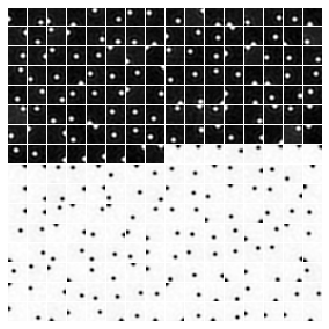

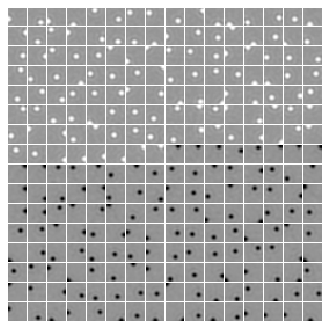

In [8]:
u0 = tonp(tr.model.layer.u_init[0].squeeze())
u1 = tonp(tr.model.layer.u_init[1].squeeze())
tr.model.show(order=np.argsort(u0), nrows=16, dpi=80)
tr.model.show(order=np.argsort(u0), nrows=16, dpi=80, method='abs-max');

In [9]:
w = tr.model.layer.get_weight().T

absmax = torch.max(w.abs(), dim=1, keepdims=True).values
w_rescaled = 0.5 * (w / absmax + 1)

w, w_rescaled = map(
    lambda t: tonp(t).reshape(-1, 16, 16),
    [w, w_rescaled],
)

w.shape, w_rescaled.shape

((256, 16, 16), (256, 16, 16))

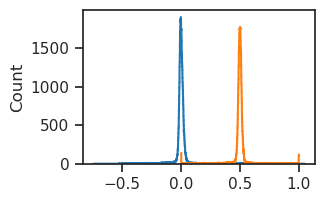

In [10]:
histplot(w.ravel());
histplot(w_rescaled.ravel());

In [11]:
%%time

dog = DifferenceOfGaussians(w).fit()

Detected 120 ON-center and 136 OFF-center cells

Found valid contours for 99 ON-center and 108 OFF-center cells

CPU times: user 2.05 s, sys: 6.82 ms, total: 2.06 s
Wall time: 2.06 s


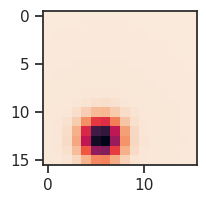

In [12]:
imshow(dog.fitted_models[7]);

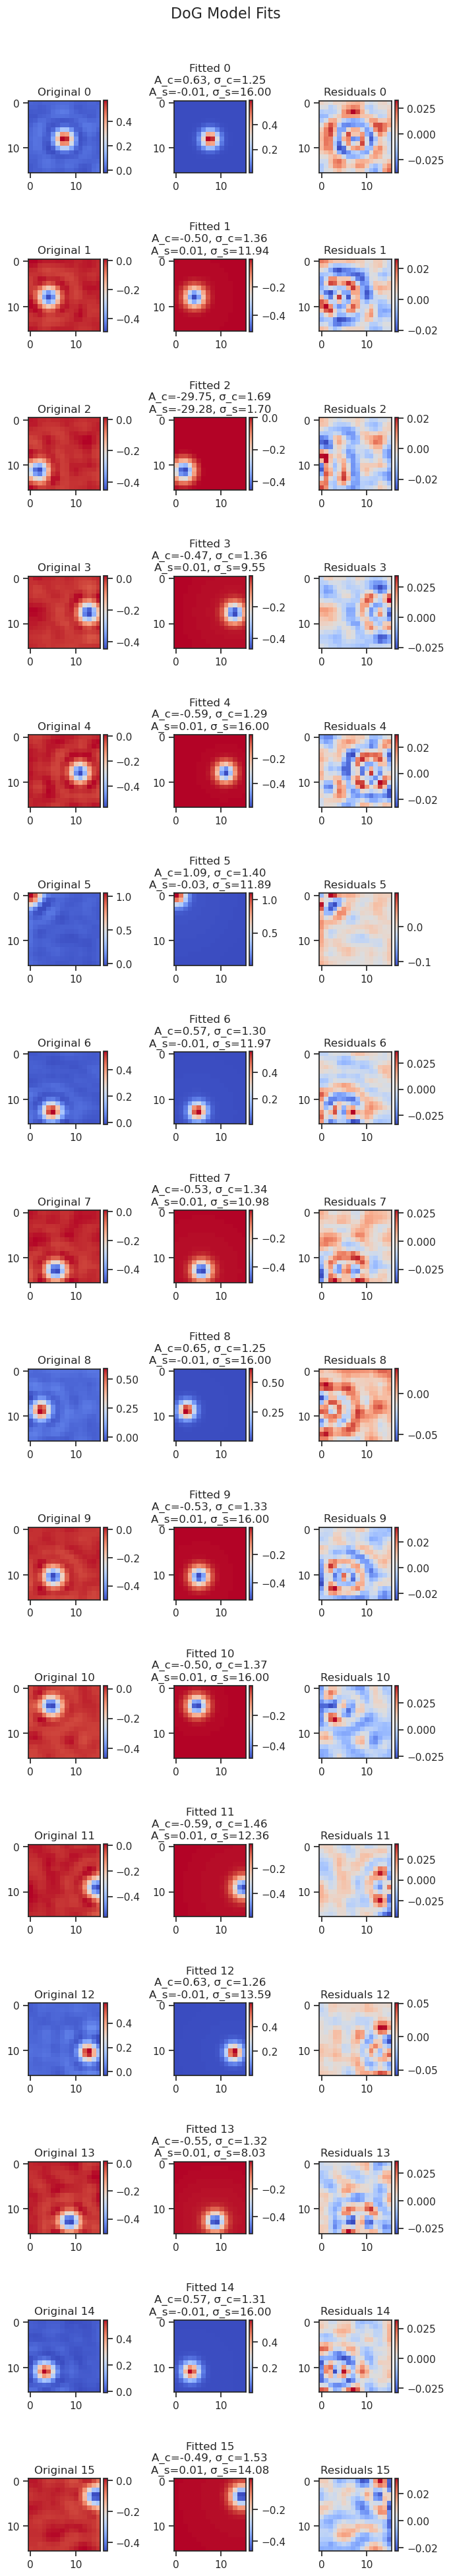

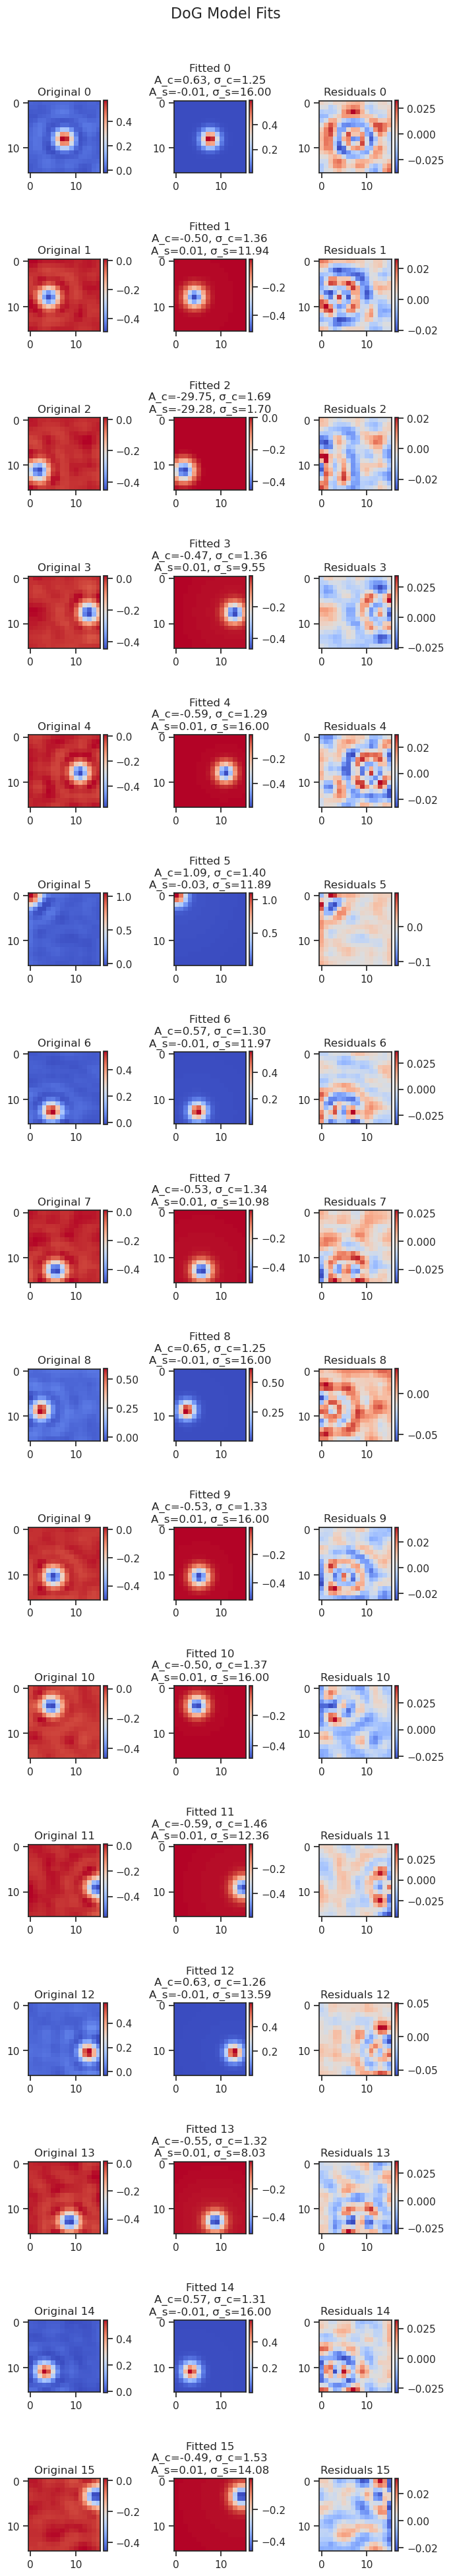

In [13]:
dog.show_fits(figsize=(7, 40))

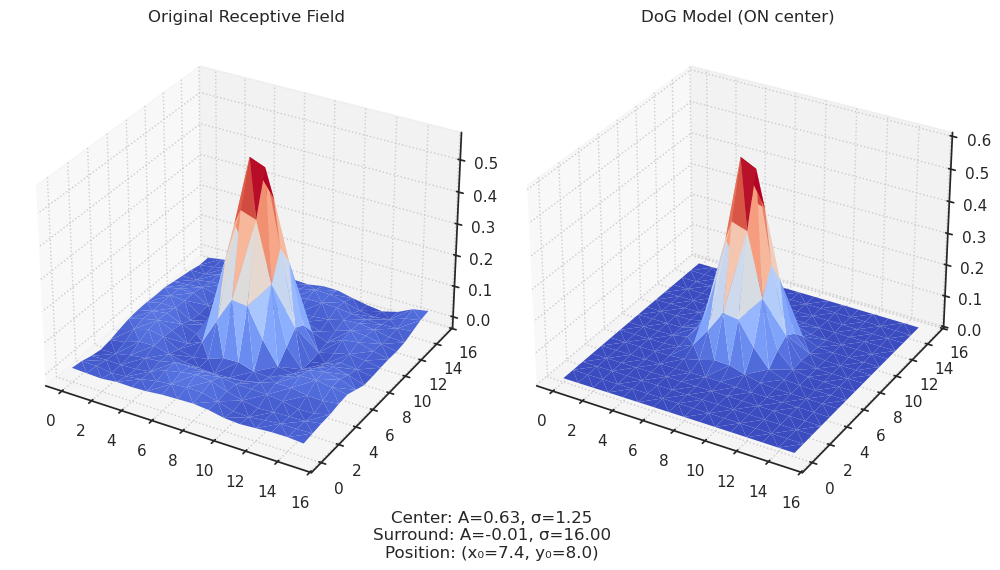

In [14]:
_ = dog.show_3d_surface(0)

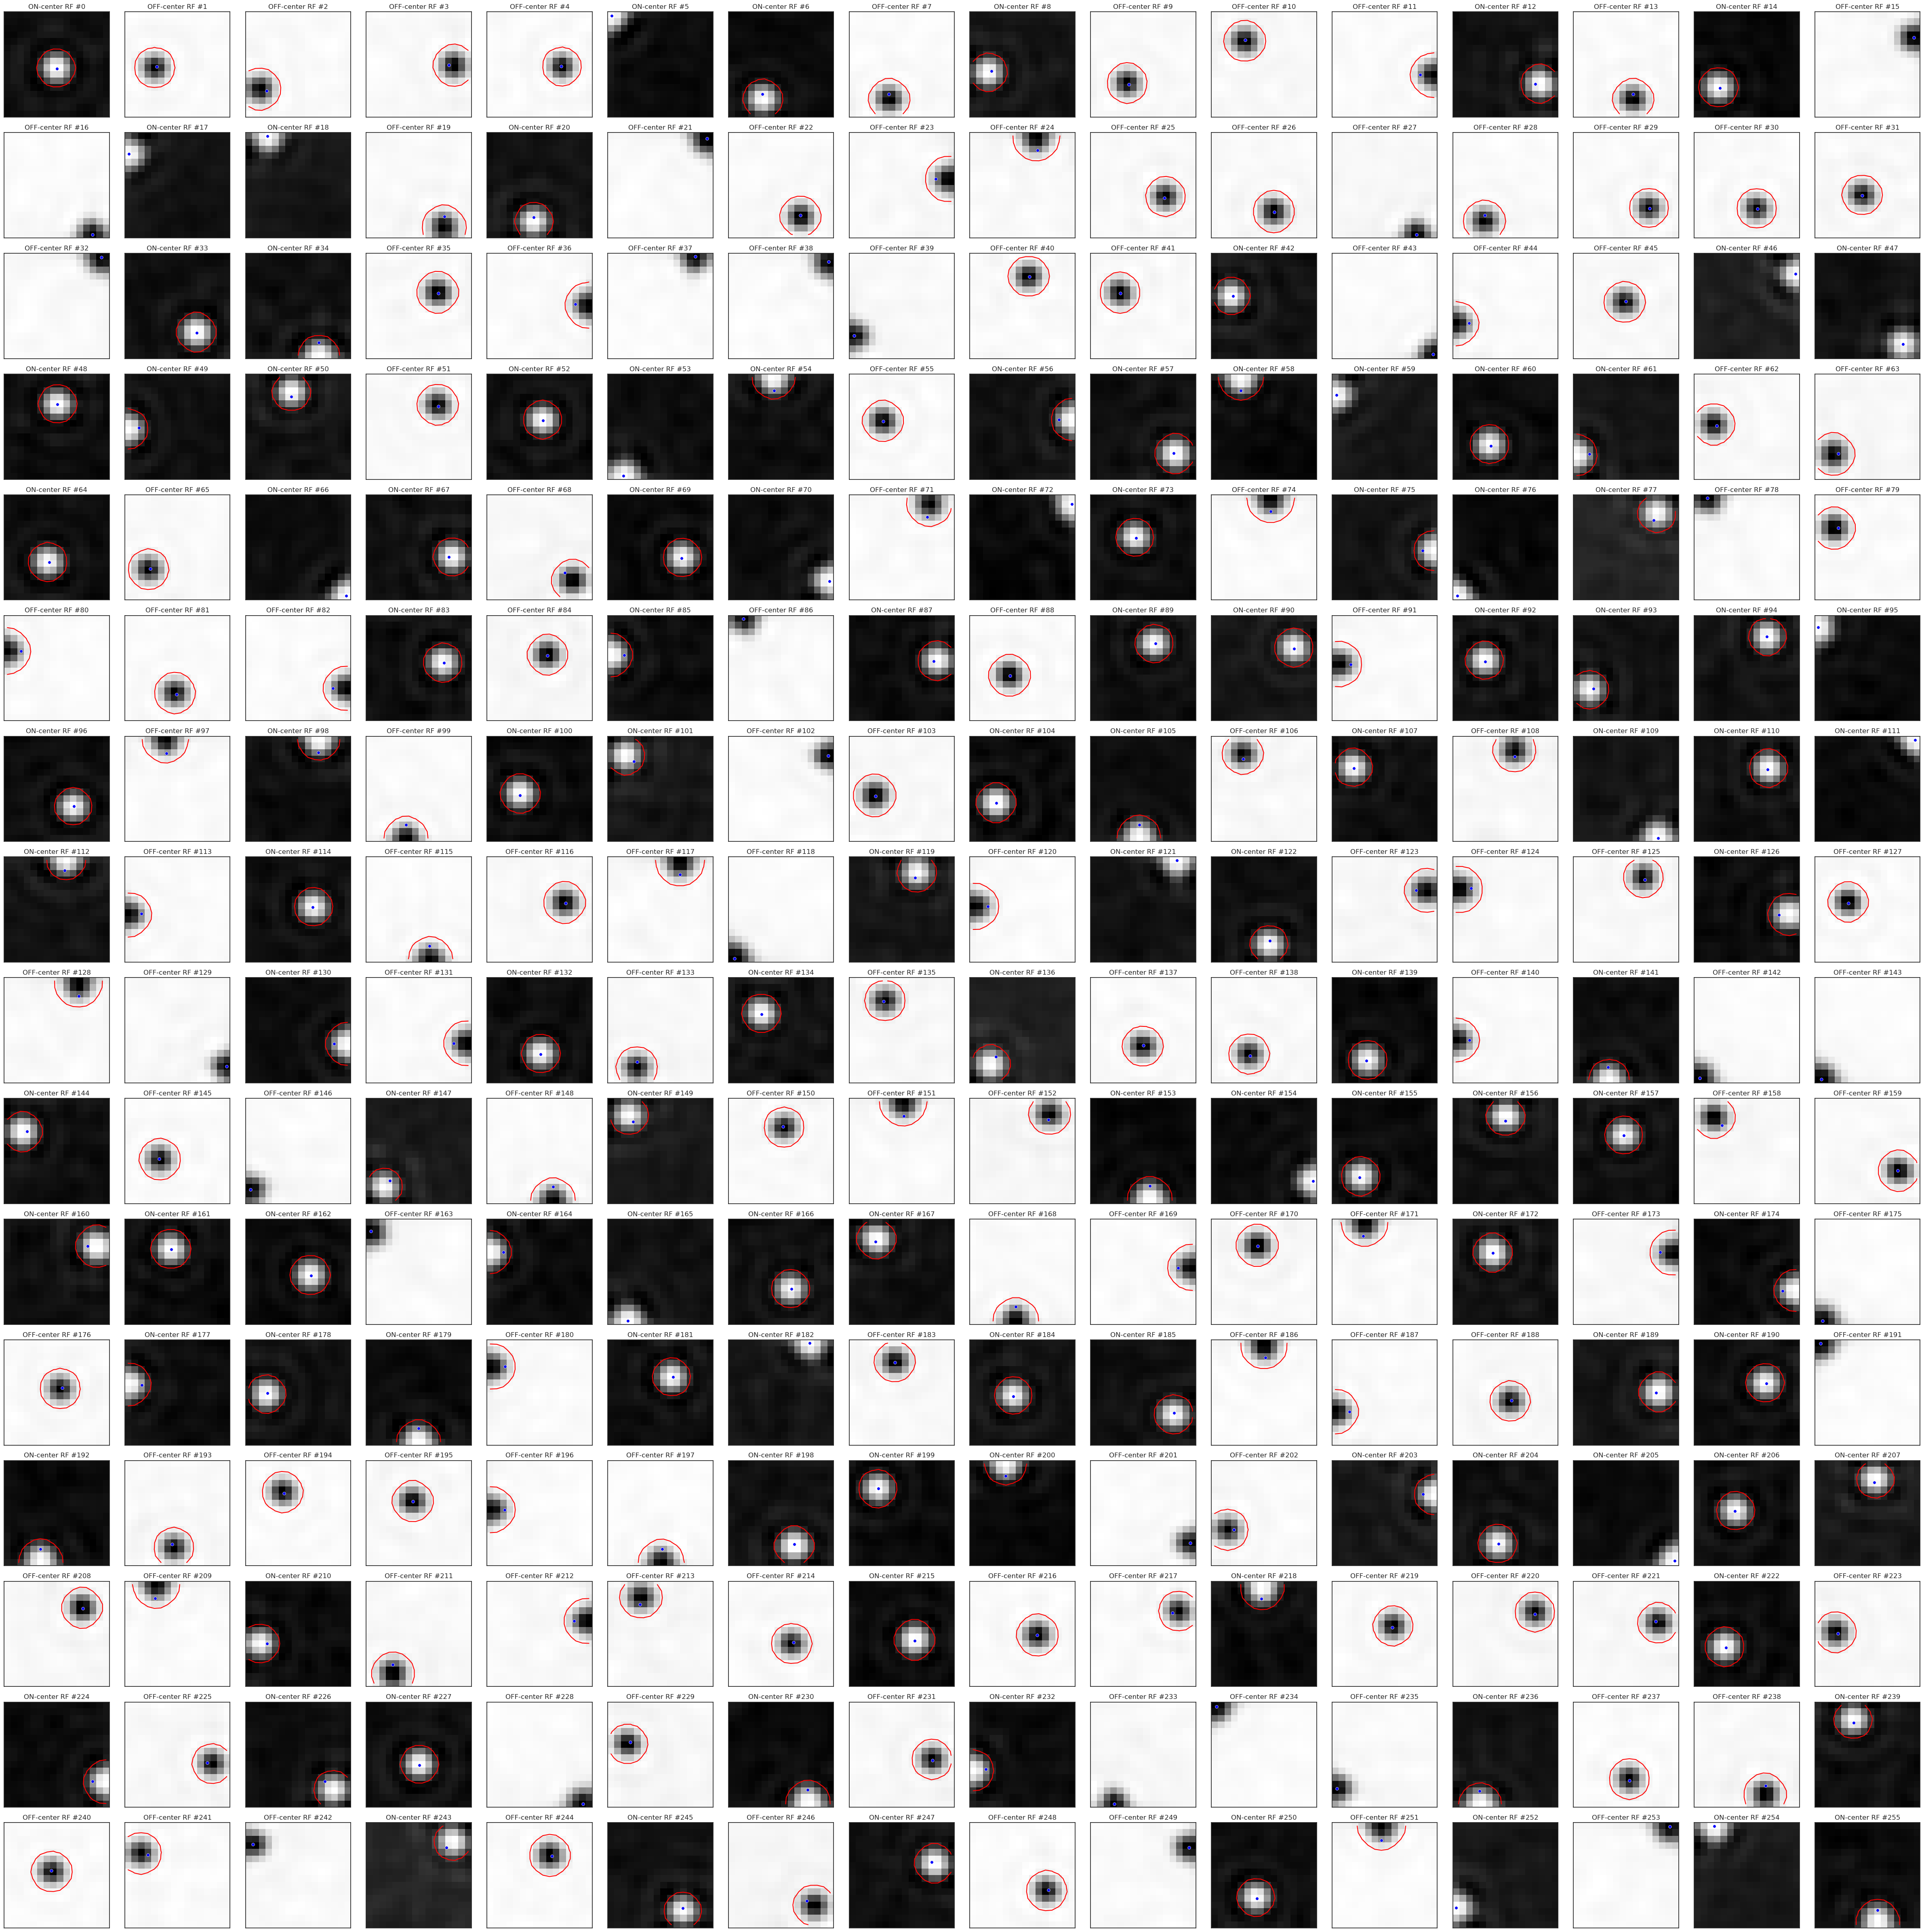

In [16]:
dog.show_contours(nrows=16);

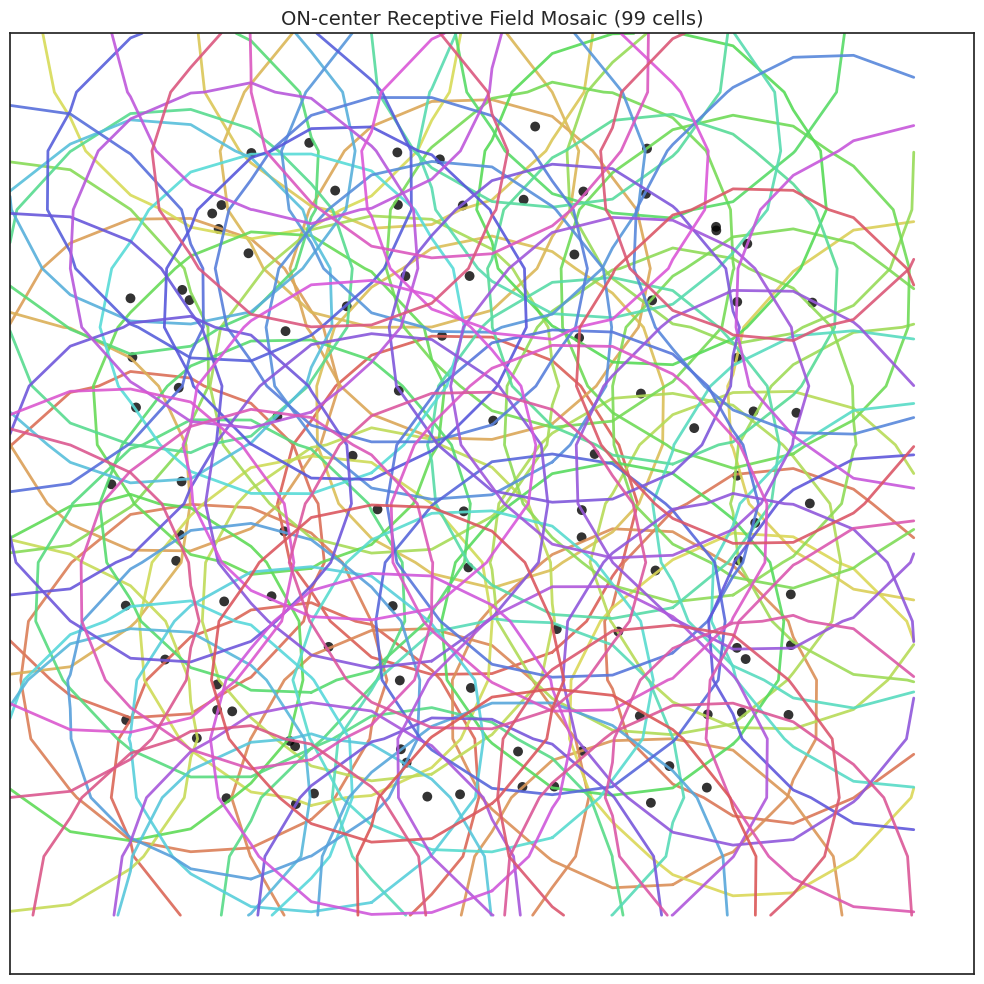

In [17]:
dog.show_mosaic(on_center=True);

In [19]:
dog.fit_contour(threshold_percent=30)

Detected 120 ON-center and 136 OFF-center cells

Found valid contours for 76 ON-center and 98 OFF-center cells

In [ ]:
plot_weights(
    w=w[np.argsort(u0)],
    method='none',
    vmin=-0.5,
    vmax=0.5,
    cmap='Greys_r',
    nrows=16,
    dpi=100,
)

plot_weights(
    w=w_rescaled[np.argsort(u0)],
    method='none',
    vmin=0,
    vmax=1,
    cmap='Greys_r',
    nrows=16,
    dpi=100,
);

In [13]:
import numpy as np
from scipy import optimize
import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D

In [42]:
def difference_of_gaussians_2d(params, x, y):
    """
    Computes a 2D Difference of Gaussians function.
    
    Parameters:
    -----------
    params : list or array
        [A_center, sigma_center, A_surround, sigma_surround, x0, y0]
        A_center: amplitude of center Gaussian
        sigma_center: standard deviation of center Gaussian
        A_surround: amplitude of surround Gaussian
        sigma_surround: standard deviation of surround Gaussian
        x0, y0: center coordinates
    x, y : arrays
        The x and y coordinates where the DoG function is evaluated
    
    Returns:
    --------
    DoG : array
        The difference of Gaussians value at each (x,y) point
    """
    A_center, sigma_center, A_surround, sigma_surround, x0, y0 = params
    
    # Center Gaussian
    center = A_center * np.exp(-((x - x0)**2 + (y - y0)**2) / (2 * sigma_center**2))
    
    # Surround Gaussian
    surround = A_surround * np.exp(-((x - x0)**2 + (y - y0)**2) / (2 * sigma_surround**2))
    
    # Difference of Gaussians
    return center - surround



def fit_dog_to_image(image, initial_params=None):
    """
    Fits a Difference of Gaussians model to a 2D image.
    
    Parameters:
    -----------
    image : 2D array
        The image data to fit
    initial_params : list or array, optional
        Initial guess for [A_center, sigma_center, A_surround, sigma_surround, x0, y0]
        If None, reasonable defaults are used based on the image size and values
    
    Returns:
    --------
    optimal_params : array
        The fitted parameters [A_center, sigma_center, A_surround, sigma_surround, x0, y0]
    model_image : 2D array
        The fitted DoG model evaluated on the image grid
    """
    # Get image dimensions and create coordinate grid
    height, width = image.shape
    y, x = np.indices((height, width))
    
    # If no initial parameters are provided, make a reasonable guess
    if initial_params is None:
        # Estimate the center of the receptive field as the peak/trough location
        if np.abs(np.max(image)) > np.abs(np.min(image)):  # ON center
            y0, x0 = np.unravel_index(np.argmax(image), image.shape)
            A_center = np.max(image)
            A_surround = -A_center / 2  # Typical surround-to-center ratio
        else:  # OFF center
            y0, x0 = np.unravel_index(np.argmin(image), image.shape)
            A_center = np.min(image)
            A_surround = -A_center / 2
        
        # Estimate Gaussian widths based on image size
        min_dim = min(height, width)
        sigma_center = min_dim / 10
        sigma_surround = min_dim / 5
        
        initial_params = [A_center, sigma_center, A_surround, sigma_surround, x0, y0]
    
    # Define the error function to minimize
    def error_function(params):
        model = difference_of_gaussians_2d(params, x, y)
        return np.ravel(model - image)
    
    # Apply constraints (all sigmas must be positive, surround sigma > center sigma)
    bounds = [(None, None),        # A_center: can be positive (ON) or negative (OFF)
              (0.1, None),         # sigma_center: must be positive
              (None, None),        # A_surround: opposite sign to center
              (0.1, None),         # sigma_surround: must be positive
              (0, width-1),        # x0: must be within image
              (0, height-1)]       # y0: must be within image
              
    # Additional constraint: surround sigma > center sigma
    constraints = [{'type': 'ineq', 'fun': lambda p: p[3] - p[1]}]
    
    # Fit the model using least squares optimization
    result = optimize.least_squares(error_function, initial_params, 
                                   bounds=(np.transpose(bounds)[0], np.transpose(bounds)[1]),
                                   method='trf')
    
    optimal_params = result.x
    
    # Generate the fitted model image
    model_image = difference_of_gaussians_2d(optimal_params, x, y)
    
    return optimal_params, model_image

In [48]:
def fit_dog_to_image(image, initial_params=None):
    """
    Fits a Difference of Gaussians model to a 2D image.
    
    Parameters:
    -----------
    image : 2D array
        The image data to fit
    initial_params : list or array, optional
        Initial guess for [A_center, sigma_center, A_surround, sigma_surround, x0, y0]
        If None, reasonable defaults are used based on the image size and values
    
    Returns:
    --------
    optimal_params : array
        The fitted parameters [A_center, sigma_center, A_surround, sigma_surround, x0, y0]
    model_image : 2D array
        The fitted DoG model evaluated on the image grid
    """
    # Get image dimensions and create coordinate grid
    height, width = image.shape
    y, x = np.indices((height, width))
    
    # If no initial parameters are provided, make a reasonable guess
    if initial_params is None:
        # Estimate the center of the receptive field as the peak/trough location
        if np.abs(np.max(image)) > np.abs(np.min(image)):  # ON center
            y0, x0 = np.unravel_index(np.argmax(image), image.shape)
            A_center = np.max(image)
            A_surround = -A_center / 2  # Typical surround-to-center ratio
        else:  # OFF center
            y0, x0 = np.unravel_index(np.argmin(image), image.shape)
            A_center = np.min(image)
            A_surround = -A_center / 2
        
        # Estimate Gaussian widths based on image size
        min_dim = min(height, width)
        sigma_center = min_dim / 10
        sigma_surround = min_dim / 5
        
        # Make sure center position is within bounds
        x0 = np.clip(x0, 0, width-1)
        y0 = np.clip(y0, 0, height-1)
        
        # Ensure sigma values are positive
        sigma_center = max(0.1, sigma_center)
        sigma_surround = max(sigma_center + 0.1, sigma_surround)  # Make sure surround sigma > center sigma
        
        initial_params = [A_center, sigma_center, A_surround, sigma_surround, x0, y0]
    
    # Define the error function to minimize
    def error_function(params):
        model = difference_of_gaussians_2d(params, x, y)
        return np.ravel(model - image)
    
    # Apply constraints (all sigmas must be positive, surround sigma > center sigma)
    bounds = [(None, None),        # A_center: can be positive (ON) or negative (OFF)
              (0.1, None),         # sigma_center: must be positive
              (None, None),        # A_surround: opposite sign to center
              (0.1, None),         # sigma_surround: must be positive
              (0, width-1),        # x0: must be within image
              (0, height-1)]       # y0: must be within image
              
    # Ensure initial parameters are within bounds
    for i, (param, (lower, upper)) in enumerate(zip(initial_params, bounds)):
        if lower is not None and param < lower:
            initial_params[i] = lower
        if upper is not None and param > upper:
            initial_params[i] = upper
              
    # Additional constraint: surround sigma > center sigma
    constraints = [{'type': 'ineq', 'fun': lambda p: p[3] - p[1]}]
    
    # Fit the model using least squares optimization
    result = optimize.least_squares(error_function, initial_params, 
                                   bounds=(np.transpose(bounds)[0], np.transpose(bounds)[1]),
                                   method='trf')
    
    optimal_params = result.x
    
    # Generate the fitted model image
    model_image = difference_of_gaussians_2d(optimal_params, x, y)
    
    return optimal_params, model_image

In [15]:
def plot_dog_results(image, model_image, params):
    """
    Plots the original image, fitted model, and residuals.
    Also shows a 3D surface plot of the DoG model.
    
    Parameters:
    -----------
    image : 2D array
        The original image data
    model_image : 2D array
        The fitted DoG model
    params : list or array
        The fitted parameters [A_center, sigma_center, A_surround, sigma_surround, x0, y0]
    """
    fig = plt.figure(figsize=(18, 10))
    
    # Extract parameters for display
    A_center, sigma_center, A_surround, sigma_surround, x0, y0 = params
    
    # Plot original image
    ax1 = fig.add_subplot(2, 3, 1)
    im1 = ax1.imshow(image, cmap='coolwarm')
    ax1.set_title('Original Receptive Field')
    plt.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)
    
    # Plot fitted model
    ax2 = fig.add_subplot(2, 3, 2)
    im2 = ax2.imshow(model_image, cmap='coolwarm')
    ax2.set_title('Fitted DoG Model')
    plt.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)
    
    # Plot residuals
    residuals = image - model_image
    ax3 = fig.add_subplot(2, 3, 3)
    im3 = ax3.imshow(residuals, cmap='coolwarm')
    ax3.set_title('Residuals')
    plt.colorbar(im3, ax=ax3, fraction=0.046, pad=0.04)
    
    # 3D surface plot of the model
    ax4 = fig.add_subplot(2, 3, 4, projection='3d')
    y, x = np.indices(image.shape)
    x = x.flatten()
    y = y.flatten()
    z = model_image.flatten()
    ax4.plot_trisurf(x, y, z, cmap='coolwarm', edgecolor='none')
    ax4.set_title('3D Surface of DoG Model')
    
    # Cross-section through the center
    ax5 = fig.add_subplot(2, 3, 5)
    center_y = int(round(params[5]))
    ax5.plot(image[center_y, :], 'b-', label='Original Data')
    ax5.plot(model_image[center_y, :], 'r-', label='DoG Model')
    ax5.set_title(f'Horizontal Cross-section (y={center_y})')
    ax5.legend()
    
    # Display the parameters
    plt.figtext(0.5, 0.01, 
                f"Center: A={A_center:.2f}, σ={sigma_center:.2f} | "
                f"Surround: A={A_surround:.2f}, σ={sigma_surround:.2f} | "
                f"Position: x₀={x0:.1f}, y₀={y0:.1f} | "
                f"{'ON center' if A_center > 0 else 'OFF center'} receptive field", 
                ha='center', fontsize=12, bbox=dict(facecolor='white', alpha=0.8))
    
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.08)
    return fig

In [20]:
# Example usage
def create_sample_dog_image(size=50, center_type='ON', noise_sgima=0.05):
    """Create a sample DoG image for testing"""
    y, x = np.indices((size, size))
    center_x, center_y = size // 2, size // 2
    
    # Parameters depend on whether it's ON or OFF center
    if center_type == 'ON':
        A_center, A_surround = 1.0, -0.5
    else:  # OFF center
        A_center, A_surround = -1.0, 0.5
    
    sigma_center = size / 10
    sigma_surround = size / 5
    
    center = A_center * np.exp(-((x - center_x)**2 + (y - center_y)**2) / (2 * sigma_center**2))
    surround = A_surround * np.exp(-((x - center_x)**2 + (y - center_y)**2) / (2 * sigma_surround**2))
    
    # Add some noise
    dog_image = center + surround + np.random.normal(0, noise_sgima, (size, size))
    
    return dog_image

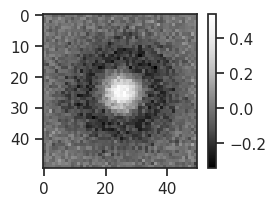

In [51]:
on_center = create_sample_dog_image(50, noise_sgima=0.05)
imshow(on_center, cmap='Greys_r')
plt.colorbar()

In [52]:
optimal_params, model_image = fit_dog_to_image(on_center)

ValueError: `x0` is infeasible.

In [ ]:
def gaussian_2d(x, y, amplitude, center_x, center_y, sigma_x, sigma_y, angle):
    cos_a, sin_a = np.cos(angle), np.sin(angle)
    xx = cos_a * (x - center_x) - sin_a * (y - center_y)
    yy = sin_a * (x - center_x) + cos_a * (y - center_y)
    g = amplitude * np.exp(-0.5 * (xx**2 / sigma_x**2 + yy**2 / sigma_y**2))
    return g

In [ ]:
# First, we'll include all the functions from the main code
def difference_of_gaussians_2d(params, x, y):
    A_center, sigma_center, A_surround, sigma_surround, x0, y0 = params

    center = A_center * np.exp(-((x - x0)**2 + (y - y0)**2) / (2 * sigma_center**2))
    surround = A_surround * np.exp(-((x - x0)**2 + (y - y0)**2) / (2 * sigma_surround**2))
    
    # Difference of Gaussians
    return center - surround

True parameters: [1.0, 5.0, -0.5, 10.0, 25, 25]

Trying manual fitting without optimization...

Manual parameters: [0.5986589107094988, 5.0, -0.2993294553547494, 10.0, 26, 25]

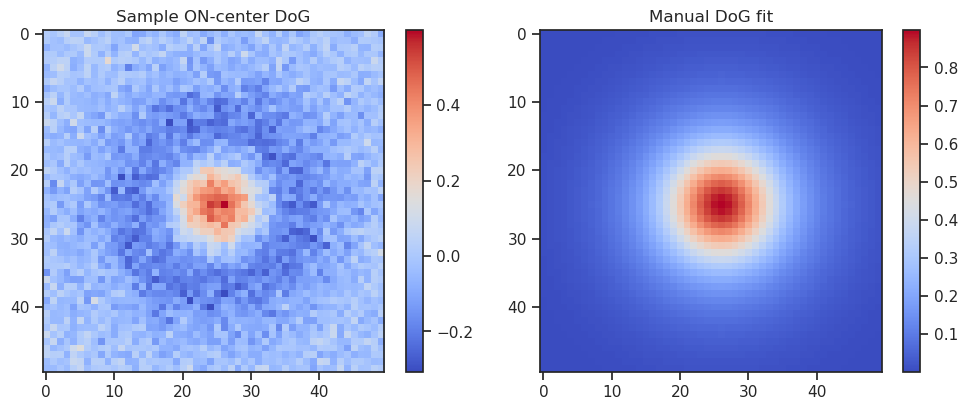

Trying optimization with explicit parameters...

Initial parameters: [1.0, 5.0, -0.5, 10.0, 25, 25]

Lower bounds: [-inf, 0.1, -inf, 0.1, 0, 0]

Upper bounds:

All initial parameters are within bounds!

Optimized parameters: [ 1.02351072  5.11038592  0.52908162  9.79464236 25.02373855 25.03212543]

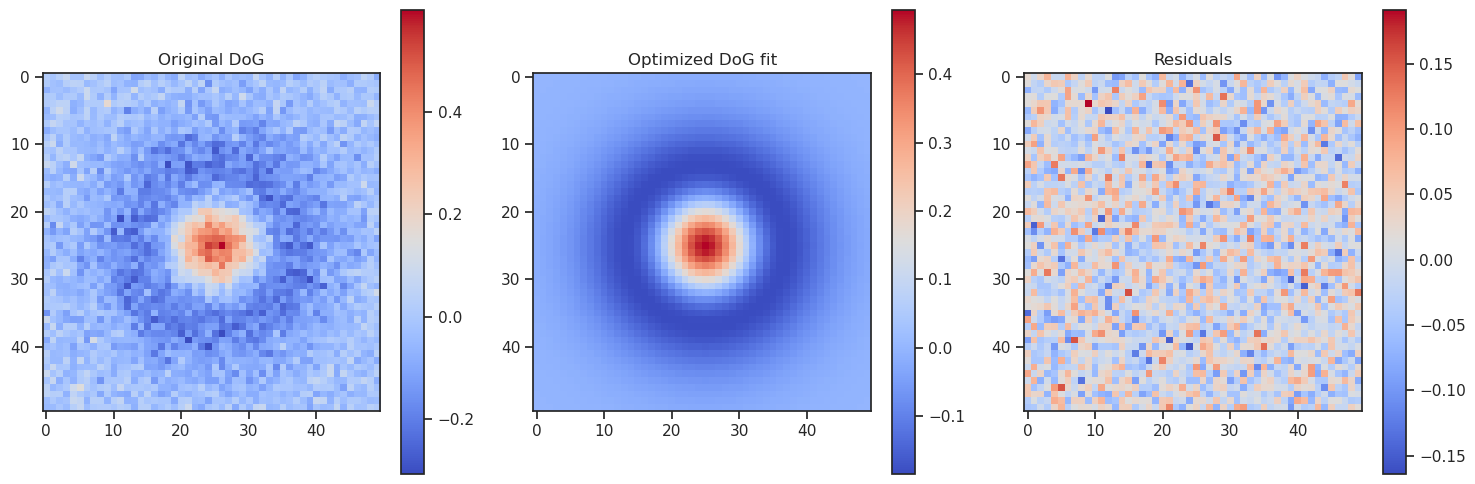

In [53]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import optimize



def create_sample_dog_image(size=50, center_type='ON'):
    y, x = np.indices((size, size))
    center_x, center_y = size // 2, size // 2
    
    # Parameters depend on whether it's ON or OFF center
    if center_type == 'ON':
        A_center, A_surround = 1.0, -0.5
    else:  # OFF center
        A_center, A_surround = -1.0, 0.5
    
    sigma_center = size / 10
    sigma_surround = size / 5
    
    # Generate DoG model
    center = A_center * np.exp(-((x - center_x)**2 + (y - center_y)**2) / (2 * sigma_center**2))
    surround = A_surround * np.exp(-((x - center_x)**2 + (y - center_y)**2) / (2 * sigma_surround**2))
    
    # Add some noise
    np.random.seed(42)  # For reproducibility
    dog_image = center + surround + np.random.normal(0, 0.05, (size, size))
    
    # Print the true parameters for debugging
    true_params = [A_center, sigma_center, A_surround, sigma_surround, center_x, center_y]
    print(f"True parameters: {true_params}")
    
    return dog_image, true_params

def fit_dog_manually(image):
    """
    A simpler version of the fitting function that avoids scipy.optimize
    to troubleshoot issues with the optimization.
    """
    height, width = image.shape
    y, x = np.indices((height, width))
    
    # Estimate center location from max/min
    if np.abs(np.max(image)) > np.abs(np.min(image)):  # ON center
        center_y, center_x = np.unravel_index(np.argmax(image), image.shape)
        A_center = np.max(image)
        A_surround = -A_center / 2
    else:  # OFF center
        center_y, center_x = np.unravel_index(np.argmin(image), image.shape)
        A_center = np.min(image)
        A_surround = -A_center / 2
    
    # Use fixed sigmas based on image size
    min_dim = min(height, width)
    sigma_center = min_dim / 10
    sigma_surround = min_dim / 5
    
    params = [A_center, sigma_center, A_surround, sigma_surround, center_x, center_y]
    
    # Generate model
    model = difference_of_gaussians_2d(params, x, y)
    
    return params, model

def debug_fitting_problem():
    """Complete test function to debug the DoG fitting issue"""
    # 1. Create sample data
    size = 50
    test_image, true_params = create_sample_dog_image(size=size, center_type='ON')
    
    # 2. Show the sample image
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(test_image, cmap='coolwarm')
    plt.colorbar()
    plt.title('Sample ON-center DoG')
    
    # 3. Try manual fitting without optimization
    print("\nTrying manual fitting without optimization...")
    manual_params, manual_model = fit_dog_manually(test_image)
    print(f"Manual parameters: {manual_params}")
    
    plt.subplot(1, 2, 2)
    plt.imshow(manual_model, cmap='coolwarm')
    plt.colorbar()
    plt.title('Manual DoG fit')
    plt.tight_layout()
    plt.show()
    
    # 4. Try optimization with explicit parameters
    print("\nTrying optimization with explicit parameters...")
    
    # Create coordinate grid
    y, x = np.indices((size, size))
    
    # Define error function
    def error_function(params):
        model = difference_of_gaussians_2d(params, x, y)
        return np.ravel(model - test_image)
    
    # Use true parameters as initial guess
    initial_params = true_params.copy()
    
    # Define bounds
    lower_bounds = [-np.inf, 0.1, -np.inf, 0.1, 0, 0]
    upper_bounds = [np.inf, np.inf, np.inf, np.inf, size-1, size-1]
    
    print(f"Initial parameters: {initial_params}")
    print(f"Lower bounds: {lower_bounds}")
    print(f"Upper bounds: {upper_bounds}")
    
    # Check if initial parameters are within bounds
    within_bounds = True
    for i, param in enumerate(initial_params):
        if param < lower_bounds[i] or param > upper_bounds[i]:
            within_bounds = False
            print(f"Parameter {i} (value {param}) is outside bounds [{lower_bounds[i]}, {upper_bounds[i]}]")
    
    if within_bounds:
        print("All initial parameters are within bounds!")
        
        try:
            result = optimize.least_squares(
                error_function, 
                initial_params, 
                bounds=(lower_bounds, upper_bounds),
                method='trf'
            )
            
            opt_params = result.x
            print(f"Optimized parameters: {opt_params}")
            
            # Create model with optimized parameters
            opt_model = difference_of_gaussians_2d(opt_params, x, y)
            
            # Plot results
            plt.figure(figsize=(15, 5))
            plt.subplot(1, 3, 1)
            plt.imshow(test_image, cmap='coolwarm')
            plt.colorbar()
            plt.title('Original DoG')
            
            plt.subplot(1, 3, 2)
            plt.imshow(opt_model, cmap='coolwarm')
            plt.colorbar()
            plt.title('Optimized DoG fit')
            
            plt.subplot(1, 3, 3)
            plt.imshow(test_image - opt_model, cmap='coolwarm')
            plt.colorbar()
            plt.title('Residuals')
            
            plt.tight_layout()
            plt.show()
            
        except Exception as e:
            print(f"Error during optimization: {e}")
    else:
        print("Cannot run optimization with out-of-bounds parameters!")

# Run the test
if __name__ == "__main__":
    debug_fitting_problem()

In [ ]:
# Example usage
def create_example_receptive_fields(n_weights=4, size=30, include_both_types=True):
	"""
	Create example receptive fields for demonstration.

	Parameters:
	-----------
	n_weights : int, default=4
		Number of receptive fields to create
	size : int, default=30
		Size of each receptive field (square)
	include_both_types : bool, default=True
		Whether to include both ON and OFF centers

	Returns:
	--------
	weights : ndarray
		Array of shape (n_weights, size, size) containing the receptive fields
	"""
	weights = np.zeros((n_weights, size, size))

	for i in range(n_weights):
		# Randomly determine ON or OFF center
		if include_both_types:
			center_type = 'ON' if i % 2 == 0 else 'OFF'
		else:
			center_type = 'ON'

		# Create coordinate grid
		y, x = np.indices((size, size))

		# Randomly position the center
		center_x = np.random.randint(size // 4, 3 * size // 4)
		center_y = np.random.randint(size // 4, 3 * size // 4)

		# Parameters depend on whether it's ON or OFF center
		if center_type == 'ON':
			A_center, A_surround = 1.0, -0.5
		else:  # OFF center
			A_center, A_surround = -1.0, 0.5

		# Randomly vary the sigmas
		sigma_center = size / (8 + np.random.rand() * 4)  # Between size/12 and size/8
		sigma_surround = sigma_center * (2 + np.random.rand())  # 2-3x the center sigma

		# Generate DoG model
		center = A_center * np.exp(-((x - center_x) ** 2 + (y - center_y) ** 2) / (2 * sigma_center ** 2))
		surround = A_surround * np.exp(-((x - center_x) ** 2 + (y - center_y) ** 2) / (2 * sigma_surround ** 2))

		# Add some noise
		weights[i] = center + surround + np.random.normal(0, 0.05, (size, size))

	return weights


# Usage example
if __name__ == "__main__":
	# Single weight example
	print("Creating single weight example...")
	size = 30
	y, x = np.indices((size, size))
	center_x, center_y = size // 2, size // 2

	# ON center
	A_center, A_surround = 1.0, -0.5
	sigma_center = size / 10
	sigma_surround = size / 5

	center = A_center * np.exp(-((x - center_x) ** 2 + (y - center_y) ** 2) / (2 * sigma_center ** 2))
	surround = A_surround * np.exp(-((x - center_x) ** 2 + (y - center_y) ** 2) / (2 * sigma_surround ** 2))

	single_weight = center + surround + np.random.normal(0, 0.05, (size, size))

	# Create and fit the model
	dog_fitter = DifferenceOfGaussiansFit(single_weight)
	dog_fitter.fit()

	# Show the results
	dog_fitter.show_weights()
	dog_fitter.show_fits()
	dog_fitter.show_3d_surface()

	# Batch example
	print("\nCreating batch example...")
	batch_weights = create_example_receptive_fields(n_weights=4, size=30)

	# Create and fit the model
	batch_fitter = DifferenceOfGaussiansFit(batch_weights)
	batch_fitter.fit()

	# Show the results
	batch_fitter.show_weights()
	batch_fitter.show_fits()
	batch_fitter.show_3d_surface(index=0)

	print("\nDone!")